# 1 Import Libraries 

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

plt.style.use("default")
sns.set_context("notebook")

# 2 Loading dataset 

In [2]:
df = pd.read_csv(r"C:\DA Projects_Pandas\Project_14\Salary_Dataset_DSL (1).csv")

# 3 Basic Dataset Understanding

In [3]:
df

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android
...,...,...,...,...,...,...,...,...
22765,4.7,Expert Solutions,Web Developer,200000,1,Bangalore,Full Time,Web
22766,4.0,Nextgen Innovation Labs,Web Developer,300000,1,Bangalore,Full Time,Web
22767,4.1,Fresher,Full Stack Web Developer,192000,13,Bangalore,Full Time,Web
22768,4.1,Accenture,Full Stack Web Developer,300000,7,Bangalore,Full Time,Web


In [4]:
df.shape

(22770, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22770 entries, 0 to 22769
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Rating             22770 non-null  float64
 1   Company Name       22769 non-null  object 
 2   Job Title          22770 non-null  object 
 3   Salary             22770 non-null  int64  
 4   Salaries Reported  22770 non-null  int64  
 5   Location           22770 non-null  object 
 6   Employment Status  22770 non-null  object 
 7   Job Roles          22770 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 1.4+ MB


In [6]:
df.describe()

,Rating,Salary,Salaries Reported
count,22770.000000,2.277000e+04,22770.000000
mean,3.918213,6.953872e+05,1.855775
std,0.519675,8.843990e+05,6.823668
min,1.000000,2.112000e+03,1.000000
25%,3.700000,3.000000e+05,1.000000
50%,3.900000,5.000000e+05,1.000000
75%,4.200000,9.000000e+05,1.000000
max,5.000000,9.000000e+07,361.000000


In [7]:
df.describe(include = "all")

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
count,22770.000000,22769,22770,2.277000e+04,22770.000000,22770,22770,22770
unique,NaN,11260,1080,NaN,NaN,10,4,11
top,NaN,Tata Consultancy Services,Software Development Engineer,NaN,NaN,Bangalore,Full Time,SDE
freq,NaN,271,2351,NaN,NaN,8264,20083,8183
mean,3.918213,NaN,NaN,6.953872e+05,1.855775,NaN,NaN,NaN
std,0.519675,NaN,NaN,8.843990e+05,6.823668,NaN,NaN,NaN
min,1.000000,NaN,NaN,2.112000e+03,1.000000,NaN,NaN,NaN
25%,3.700000,NaN,NaN,3.000000e+05,1.000000,NaN,NaN,NaN
50%,3.900000,NaN,NaN,5.000000e+05,1.000000,NaN,NaN,NaN
75%,4.200000,NaN,NaN,9.000000e+05,1.000000,NaN,NaN,NaN


# 4 Data Cleaing 
  - Check the values

In [8]:
df.isnull().sum()

Rating               0
Company Name         1
Job Title            0
Salary               0
Salaries Reported    0
Location             0
Employment Status    0
Job Roles            0
dtype: int64

- Remove Duplicate Rows

In [9]:
df = df.drop_duplicates()

In [10]:
df

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android
...,...,...,...,...,...,...,...,...
22765,4.7,Expert Solutions,Web Developer,200000,1,Bangalore,Full Time,Web
22766,4.0,Nextgen Innovation Labs,Web Developer,300000,1,Bangalore,Full Time,Web
22767,4.1,Fresher,Full Stack Web Developer,192000,13,Bangalore,Full Time,Web
22768,4.1,Accenture,Full Stack Web Developer,300000,7,Bangalore,Full Time,Web


# 5 outlier Detection & Removal 
- Visuilize Salary ouliers


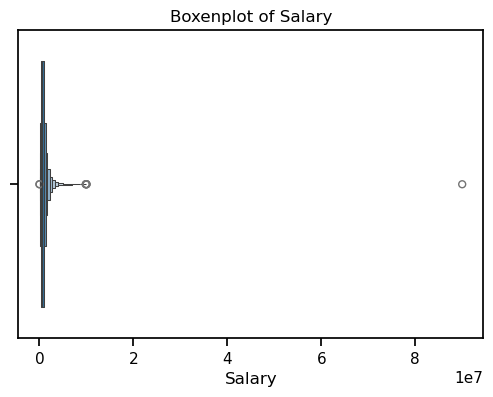

In [11]:
plt.figure(figsize = (6, 4))
sns.boxenplot(x = df['Salary'])

plt.title("Boxenplot of Salary")
plt.show()

- IQR (Interquartile Range) Method

In [12]:
Q1 = df['Salary'].quantile(0.25)
Q3 = df['Salary'].quantile(0.75)

IQR = Q3 - Q1

In [13]:
Lower_limit = Q1 - 1.5 * IQR
Upper_limit = Q3 + 1.5 * IQR

In [14]:
df = df[(df['Salary'] >= Lower_limit) & (df['Salary'] <= Upper_limit)]

In [15]:
df

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android
...,...,...,...,...,...,...,...,...
22765,4.7,Expert Solutions,Web Developer,200000,1,Bangalore,Full Time,Web
22766,4.0,Nextgen Innovation Labs,Web Developer,300000,1,Bangalore,Full Time,Web
22767,4.1,Fresher,Full Stack Web Developer,192000,13,Bangalore,Full Time,Web
22768,4.1,Accenture,Full Stack Web Developer,300000,7,Bangalore,Full Time,Web


# 6 Univariate Analysis

- Salary Distribution

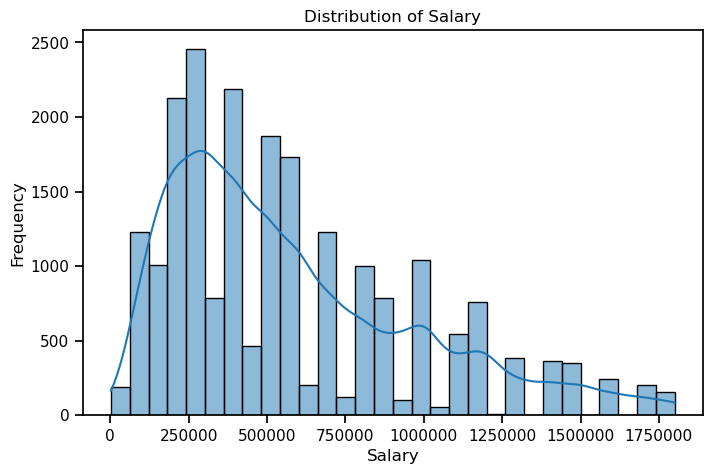

In [16]:
plt.figure(figsize = (8, 5))
sns.histplot(df['Salary'],bins = 30,kde = True)
plt.ticklabel_format(style = "plain", axis = "x")

plt.title("Distribution of Salary")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.show()


# 7 Answering Business Questions

Q1: Which Job Roles have Highest Average Salary ?

In [17]:
df

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android
...,...,...,...,...,...,...,...,...
22765,4.7,Expert Solutions,Web Developer,200000,1,Bangalore,Full Time,Web
22766,4.0,Nextgen Innovation Labs,Web Developer,300000,1,Bangalore,Full Time,Web
22767,4.1,Fresher,Full Stack Web Developer,192000,13,Bangalore,Full Time,Web
22768,4.1,Accenture,Full Stack Web Developer,300000,7,Bangalore,Full Time,Web


In [18]:
df['Job Roles'].nunique()

11

In [19]:
df['Job Roles'].unique()

array(['Android', 'Backend', 'Database', 'Frontend', 'IOS', 'Java',
       'Mobile', 'SDE', 'Python', 'Web', 'Testing'], dtype=object)

In [20]:
Job_Salary = df.groupby('Job Roles')['Salary'].mean().sort_values(ascending = False).head(10)

In [21]:
Job_Salary

Job Roles
Database    745670.833333
SDE         693104.775386
Mobile      648251.121076
IOS         617741.013470
Backend     574203.926740
Frontend    532927.754789
Android     501886.106443
Java        493755.957895
Testing     474144.130006
Python      460101.327641
Name: Salary, dtype: float64

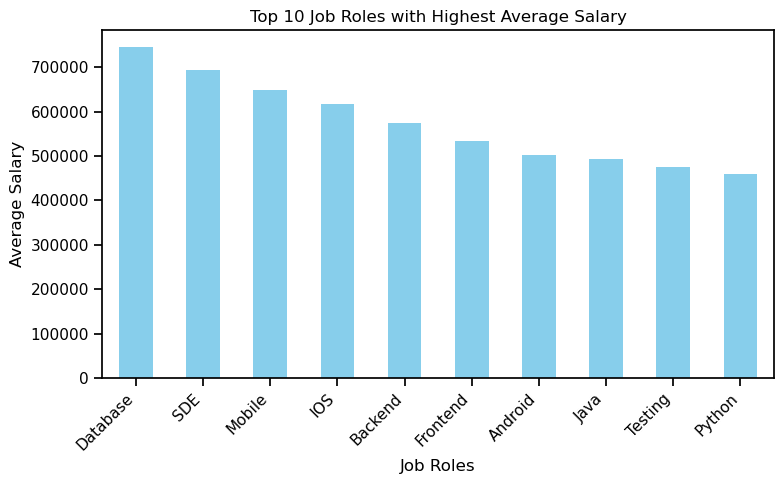

In [22]:
plt.figure(figsize=(8,5))
Job_Salary.plot(kind = "bar", x  = Job_Salary.index, y = Job_Salary.values, color = "skyblue")
plt.title("Top 10 Job Roles with Highest Average Salary")
plt.xlabel("Job Roles")
plt.ylabel("Average Salary")
plt.xticks(rotation = 45, ha = "right")
plt.tight_layout()
plt.show()

Q2: Which Cities ffer Hight Average Salary?

In [23]:
df

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android
...,...,...,...,...,...,...,...,...
22765,4.7,Expert Solutions,Web Developer,200000,1,Bangalore,Full Time,Web
22766,4.0,Nextgen Innovation Labs,Web Developer,300000,1,Bangalore,Full Time,Web
22767,4.1,Fresher,Full Stack Web Developer,192000,13,Bangalore,Full Time,Web
22768,4.1,Accenture,Full Stack Web Developer,300000,7,Bangalore,Full Time,Web


In [24]:
city_salary = df.groupby('Location')['Salary'].mean().sort_values(ascending = False)

In [25]:
city_salary

Location
Mumbai            752751.976155
Bangalore         606592.401189
Pune              594584.661125
Hyderabad         571350.134149
Kolkata           566359.281437
Jaipur            566153.846154
New Delhi         564724.843308
Chennai           523388.068763
Kerala            514965.735849
Madhya Pradesh    505600.644295
Name: Salary, dtype: float64

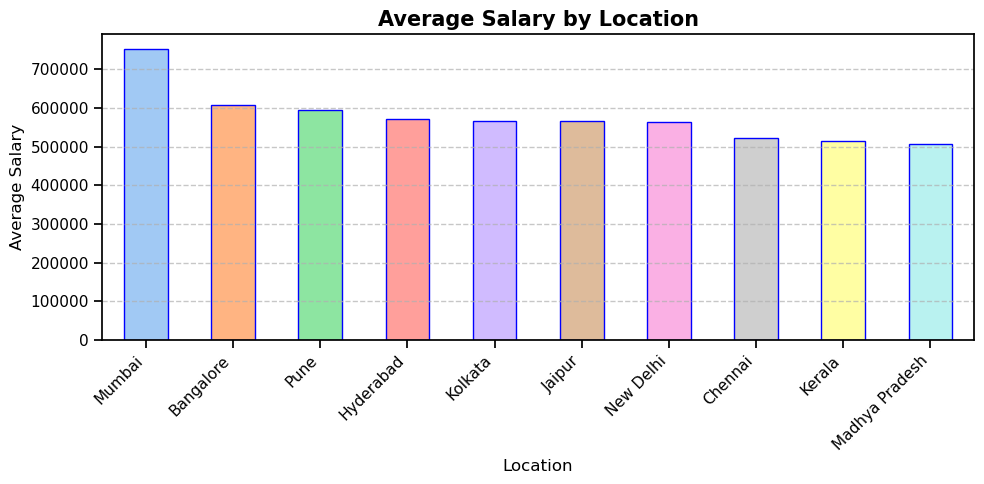

In [26]:
plt.figure(figsize = (10, 5))

colors = sns.color_palette("pastel", len(city_salary))

city_salary.plot(kind= "bar", color= colors, edgecolor = "blue") 
plt.title("Average Salary by Location", fontsize = 15, fontweight = "bold")
plt.xlabel("Location")  
plt.ylabel("Average Salary")
plt.xticks(rotation = 45, ha = "right")
plt.grid(axis = "y", linestyle = "--", alpha = 0.7)
plt.tight_layout()
plt.show()  

Q3: Name those 5 Companies Located in 'New Delhi' With Ratong of '5', offering hight & 
Lowest Salaries

In [27]:
df

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android
...,...,...,...,...,...,...,...,...
22765,4.7,Expert Solutions,Web Developer,200000,1,Bangalore,Full Time,Web
22766,4.0,Nextgen Innovation Labs,Web Developer,300000,1,Bangalore,Full Time,Web
22767,4.1,Fresher,Full Stack Web Developer,192000,13,Bangalore,Full Time,Web
22768,4.1,Accenture,Full Stack Web Developer,300000,7,Bangalore,Full Time,Web


In [28]:
df1 = df[(df['Location'] == "New Delhi") & (df['Rating'] == 5)].sort_values(by = "Salary", ascending = False)

In [29]:
list(df1['Company Name'].head(5))

['Firevol',
 'Trillbit',
 'Hapramp',
 'The Art of Mike Mignola',
 'Silicon Valley Recycling']

In [30]:
list(df1['Company Name'].tail())


['Rabbler', 'WorkingNation', 'Hopin (India)', 'Star Catalysts', 'Atom 8']

Q.4) Which Job Title Has The Highest number of Salary reported ?

In [31]:
df.head()

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android


In [34]:
df['Job Title'].value_counts()

Job Title
Software Development Engineer          2225
Android Developer                      1998
Software Development Engineer (SDE)    1528
Front End Developer                    1384
Test Engineer                          1301
                                       ... 
Test Engineer Senior Analyst              1
Manual QA Tester                          1
Test Engineer Analyst                     1
Testing Executive                         1
Backend Engineering                       1
Name: count, Length: 1014, dtype: int64

In [35]:
df.groupby('Job Title')['Salaries Reported'].count().sort_values(ascending= False)

Job Title
Software Development Engineer                        2225
Android Developer                                    1998
Software Development Engineer (SDE)                  1528
Front End Developer                                  1384
Test Engineer                                        1301
                                                     ... 
Trainee Android Developer                               1
Trainee Test Engineer - Contractor                      1
UI/UX Designer & Front End Developer                    1
UI/User Experience Designer & Front End Developer       1
Testing Executive                                       1
Name: Salaries Reported, Length: 1014, dtype: int64

Q.15) Which 10 Companies Provide the hight average salary, when at least 20 employees have repoted their salaries

In [36]:
df.head()

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android


In [ ]:
filtered_df = df[df['Salaries Reported'] >= 20]

filtered_df

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
8790,3.9,Tata Consultancy Services,Java Developer,200000,30,Chennai,Full Time,Java
8977,3.8,Cognizant Technology Solutions,Senior Java Developer,200000,35,Chennai,Full Time,Java
8978,3.9,Tata Consultancy Services,Senior Java Developer,300000,30,Chennai,Full Time,Java
8979,3.9,Tata Consultancy Services,Junior Java Developer,200000,30,Chennai,Full Time,Java
9688,3.9,Tata Consultancy Services,Java Developer,200000,43,Hyderabad,Full Time,Java
...,...,...,...,...,...,...,...,...
21762,3.8,CGI,Senior Test Engineer,400000,21,Bangalore,Full Time,Testing
21763,4.1,IBM,Test Automation Engineer,400000,21,Bangalore,Full Time,Testing
21764,3.7,SLK Group,Software Test Engineer,300000,20,Bangalore,Full Time,SDE
21765,4.3,Cisco Systems,Software Test Engineer,700000,20,Bangalore,Full Time,SDE


In [41]:
filtered_df.groupby('Company Name')['Salary'].mean().sort_values(ascending = False).head(10)

Company Name
Expedia Group        1.350000e+06
Cisco Systems        1.250000e+06
Amadeus              1.200000e+06
Nokia                1.200000e+06
Alcatel-Lucent       1.000000e+06
Dell Technologies    1.000000e+06
Ola                  1.000000e+06
Kony                 9.000000e+05
Lumen                9.000000e+05
Microsoft            7.845714e+05
Name: Salary, dtype: float64

Q.5) Check and show the relationship Between Rating & Salaries. 

In [42]:
df

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android
...,...,...,...,...,...,...,...,...
22765,4.7,Expert Solutions,Web Developer,200000,1,Bangalore,Full Time,Web
22766,4.0,Nextgen Innovation Labs,Web Developer,300000,1,Bangalore,Full Time,Web
22767,4.1,Fresher,Full Stack Web Developer,192000,13,Bangalore,Full Time,Web
22768,4.1,Accenture,Full Stack Web Developer,300000,7,Bangalore,Full Time,Web


In [48]:
df['Rating'].corr(df['Salary'])

np.float64(0.028435446014226973)

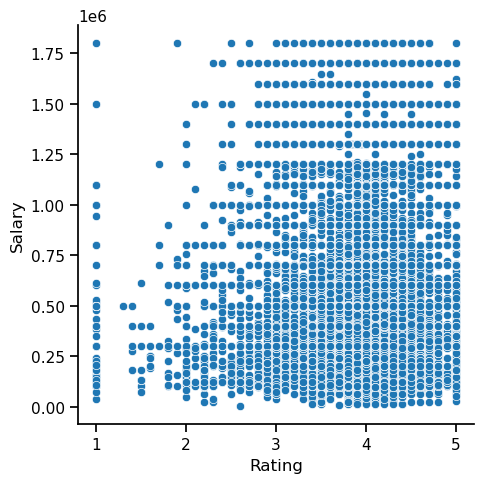

In [49]:
sns.relplot(x='Rating', y='Salary', data=df)

plt.show()

Q.6) Does employment status affect salary?

In [51]:
df

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android
...,...,...,...,...,...,...,...,...
22765,4.7,Expert Solutions,Web Developer,200000,1,Bangalore,Full Time,Web
22766,4.0,Nextgen Innovation Labs,Web Developer,300000,1,Bangalore,Full Time,Web
22767,4.1,Fresher,Full Stack Web Developer,192000,13,Bangalore,Full Time,Web
22768,4.1,Accenture,Full Stack Web Developer,300000,7,Bangalore,Full Time,Web


In [52]:
df['Employment Status'].unique()

array(['Full Time', 'Intern', 'Contractor', 'Trainee'], dtype=object)

In [53]:
df['Employment Status'].value_counts()

Employment Status
Full Time     18966
Intern         2092
Contractor      523
Trainee          33
Name: count, dtype: int64

In [54]:
df.groupby('Employment Status')['Salary'].describe()

,count,mean,std,min,25%,50%,75%,max
Employment Status,,,,,,,,
Contractor,523.0,523849.697897,351437.182096,12000.0,300000.0,408000.0,678000.0,1800000.0
Full Time,18966.0,613544.648740,401432.268284,8448.0,300000.0,500000.0,876000.0,1800000.0
Intern,2092.0,340258.837476,268760.067534,2112.0,144000.0,276000.0,456000.0,1800000.0
Trainee,33.0,324303.030303,241096.516572,96000.0,144000.0,240000.0,400000.0,1100000.0


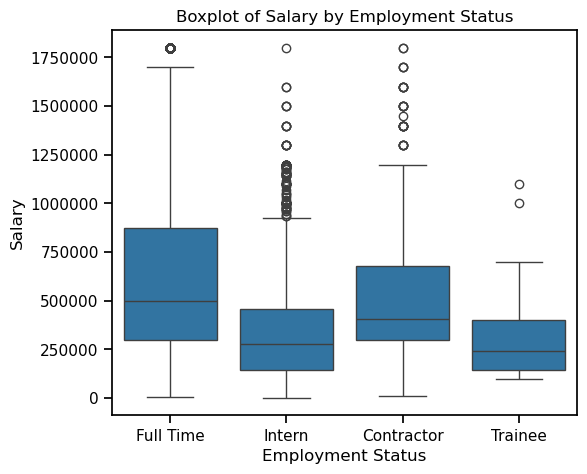

In [57]:
plt.figure(figsize = (6, 5))

sns.boxplot(x = "Employment Status", y = "Salary", data = df)

plt.ticklabel_format(style = "plain", axis = "y")

plt.title("Boxplot of Salary by Employment Status")
plt.xlabel("Employment Status")
plt.ylabel("Salary")

plt.show()